# Multi-Stage Inventory Control (Flower Girl Problem)

## Problem Statement

A flower seller operates over $T$ days:
- Each morning, buy $u_t \in [0, U]$ flowers at cost $c$ per unit
- During the day, sell up to demand $d_t \sim \text{Uniform}\{1, \ldots, D\}$ at price $p$ per unit
- Unsold flowers carry over to the next day
- After day $T$, all remaining stock is lost

**Objective:** Minimize expected total cost over $T$ days.

$$\min \; \mathbb{E}\left[\sum_{t=1}^T c \cdot u_t - p \cdot \min(x_t + u_t, d_t)\right]$$

Subject to non-anticipativity: $u_t$ can only depend on information available at time $t$.

---

## Key Concepts
1. **Extensive formulation** — exact solution for small problems
2. **Anticipative bound** — lower bound (perfect information)
3. **Two-stage relaxation** — tractable lower bound
4. **Policy simulation** — evaluate heuristics via Monte Carlo
5. **Model Predictive Control** — rolling horizon approach

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.inventory import (
    solve_extensive_form,
    anticipative_bound,
    simulate_policy,
    constant_policy,
    best_constant_policy,
    mpc_policy,
)
from src.utils import generate_scenarios, format_result

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Problem parameters
c, p = 1.0, 2.0
D, U, T = 10, 7, 10
print(f"Flower Girl Problem: c={c}, p={p}, D={D}, U={U}, T={T}")
print(f"Demand: Uniform{{1, ..., {D}}}, E[d] = {(D+1)/2:.1f}")

Flower Girl Problem: c=1.0, p=2.0, D=10, U=7, T=10
Demand: Uniform{1, ..., 10}, E[d] = 5.5


## 1. Exact Solution for Small Problems (T=1, T=2)

The extensive formulation enumerates all possible scenarios and enforces non-anticipativity constraints. This is only feasible for small $T$ due to the exponential growth of scenarios ($D^T$).

In [2]:
# T=1 case (reduces to newsvendor)
val_T1, u_T1 = solve_extensive_form(T=1, D=D, c=c, p=p, U=U)
print(f"T=1: Optimal value = {val_T1:.4f}, Optimal first purchase = {u_T1[0]:.2f}")

# T=2 case
val_T2, u_T2 = solve_extensive_form(T=2, D=D, c=c, p=p, U=U)
print(f"T=2: Optimal value = {val_T2:.4f}, Optimal first purchase = {u_T2[0]:.2f}")

print(f"\nNote: For T={T}, the extensive form would need {D**T:.0e} scenarios — intractable!")

T=1: Optimal value = -3.0000, Optimal first purchase = 6.00
T=2: Optimal value = -7.9000, Optimal first purchase = 7.00

Note: For T=10, the extensive form would need 1e+10 scenarios — intractable!


## 2. Bounds for the Full Problem (T=10)

Since the exact solution is intractable, we compute **bounds**:

- **Lower bound (Anticipative):** Solve assuming perfect knowledge of future demand
- **Upper bound (Feasible policy):** Evaluate any non-anticipative policy

The gap between bounds quantifies our uncertainty about the true optimal value.

In [3]:
# Generate test scenarios
n_mc = 500
scenarios = generate_scenarios(n_mc, T, D, seed=42)
print(f"Generated {n_mc} demand scenarios of length T={T}")
print(f"Sample scenario: {scenarios[0]}")

Generated 500 demand scenarios of length T=10
Sample scenario: [1 8 7 5 5 9 1 7 3 1]


In [4]:
# Anticipative (perfect information) lower bound
ant_mean, ant_ci = anticipative_bound(scenarios, c, p, U)
print(f"Anticipative lower bound: {format_result(ant_mean, ant_ci, 'LB')}")

Anticipative lower bound: LB: -53.47 ± 0.70 (95% CI)


## 3. Heuristic Policies

### 3.1 Constant Purchase Policy
Buy the same amount every day regardless of stock level.

In [5]:
# Evaluate constant policies
u_values = np.arange(0, U + 1, 1.0)
costs_by_u = []

print(f"{'u (constant)':<15} {'Expected Cost':<15} {'95% CI'}")
print('-' * 50)
for u_val in u_values:
    cost, ci = simulate_policy(scenarios, constant_policy(u_val), c, p, U)
    costs_by_u.append(cost)
    print(f"{u_val:<15.1f} {cost:<15.2f} ±{ci:.2f}")

best_idx = np.argmin(costs_by_u)
print(f"\n→ Best constant policy: u = {u_values[best_idx]:.1f}, cost = {costs_by_u[best_idx]:.2f}")

u (constant)    Expected Cost   95% CI
--------------------------------------------------
0.0             0.00            ±0.00
1.0             -10.00          ±0.00
2.0             -19.74          ±0.07
3.0             -28.96          ±0.19
4.0             -37.11          ±0.38
5.0             -42.50          ±0.74
6.0             -42.40          ±1.13
7.0             -36.94          ±1.40

→ Best constant policy: u = 5.0, cost = -42.50


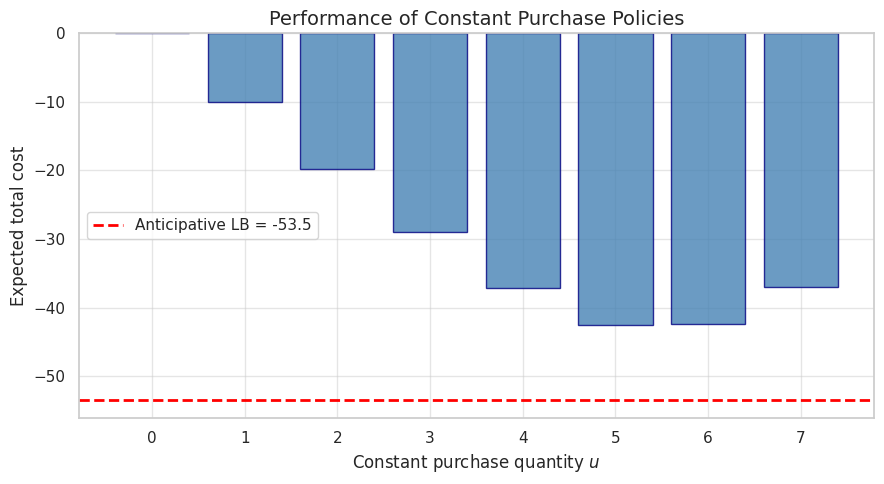

In [6]:
# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(u_values, costs_by_u, color='steelblue', alpha=0.8, edgecolor='navy')
ax.axhline(ant_mean, color='red', linestyle='--', linewidth=2, label=f'Anticipative LB = {ant_mean:.1f}')
ax.set_xlabel('Constant purchase quantity $u$', fontsize=12)
ax.set_ylabel('Expected total cost', fontsize=12)
ax.set_title('Performance of Constant Purchase Policies', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 3.2 Model Predictive Control (MPC)

At each step, solve a deterministic optimization using the **expected demand** as forecast, then apply only the first-stage decision. This is a common industrial approach.

In [7]:
# MPC policy
mpc_pol = mpc_policy(T, D, c, p, U)
mpc_cost, mpc_ci = simulate_policy(scenarios, mpc_pol, c, p, U)
print(f"MPC policy: {format_result(mpc_cost, mpc_ci, 'MPC')}")
print(f"Best constant: {costs_by_u[best_idx]:.2f}")
print(f"Anticipative LB: {ant_mean:.2f}")
print(f"\nMPC improvement over best constant: {costs_by_u[best_idx] - mpc_cost:.2f}")

MPC policy: MPC: -46.81 ± 0.63 (95% CI)
Best constant: -42.50
Anticipative LB: -53.47

MPC improvement over best constant: 4.31


## 4. Comparison of All Approaches

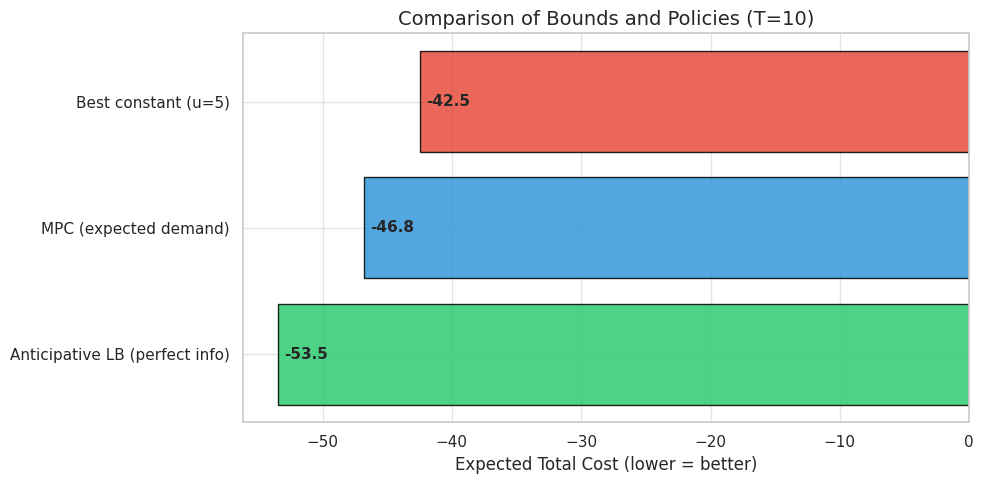


Optimality gap (UB - LB): 10.97
MPC gap: 6.66


In [8]:
# Summary comparison
results = {
    'Anticipative LB (perfect info)': ant_mean,
    'MPC (expected demand)': mpc_cost,
    f'Best constant (u={u_values[best_idx]:.0f})': costs_by_u[best_idx],
}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
values = list(results.values())
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.barh(names, values, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel('Expected Total Cost (lower = better)', fontsize=12)
ax.set_title('Comparison of Bounds and Policies (T=10)', fontsize=14)

for bar, val in zip(bars, values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nOptimality gap (UB - LB): {costs_by_u[best_idx] - ant_mean:.2f}")
print(f"MPC gap: {mpc_cost - ant_mean:.2f}")

## Summary

| Method | Type | Value |
|--------|------|-------|
| Anticipative | Lower Bound | Best possible (hindsight) |
| MPC | Feasible Policy | Good but not optimal |
| Best Constant | Feasible Policy | Simple benchmark |

### Notes
- The **anticipative bound** gives us an unachievable ideal (Value of Perfect Information)
- **MPC** significantly outperforms naive constant policies
- The gap between bounds quantifies how much room for improvement remains
- For exact solutions, we need **Dynamic Programming** (see Notebook 03)